# Stratigraphic Contact Gate — interval-valued gamma evidence

## tl;dr

On a strict 272-well holdout grouped by exact typewell profile and scored on all
1,324,387 missing-TVT rows, the inherited inference-safe baseline scores **14.834 ft
pooled RMSE**. Equal-cell typewell evidence reaches **14.437 ft**; calibrated ordered
stay/cross/reverse transport reaches **14.501 ft**. Their development-only joint
correction reaches **14.142 ft**, a **0.692 ft** improvement with an exact-typewell-group
bootstrap interval of approximately **+0.350 to +1.025 ft**.

This is a valid **MEASURE_ONLY** result, not OPEN. The fusion was proposed after the
component results on this holdout were inspected, so it must survive a newly frozen
outer-fold evaluation before supporting a generalized or IP performance claim.

## Sealed validation update — answer first

The earlier strict-holdout experiment remains intact below. This inserted section is
the current decision surface: it loads only the sealed repeated-group and spatial
artifacts, verifies their hashes, and derives every displayed result from those files.
The two gates answer different questions, so their statuses must not be collapsed into
one generic “pass.”

In [1]:
from pathlib import Path
import hashlib
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

SEALED_ROOT_HINT = Path(r"C:\PRIMEdEV-1\GeoSteerN-Codex\.claude\worktrees\well-datum-surface-fit-e24e6c")
sealed_root_candidates = [Path.cwd(), *Path.cwd().parents, SEALED_ROOT_HINT]
SEALED_ROOT = next(
    (path for path in sealed_root_candidates
     if (path / "research" / "results" / "equal_ordered_joint_outer_repeated.json").exists()),
    None,
)
if SEALED_ROOT is None:
    raise FileNotFoundError("Cannot locate the sealed research/results artifacts.")

SEALED_RESULT_DIR = SEALED_ROOT / "research" / "results"
sealed_paths = {
    "repeated result": SEALED_RESULT_DIR / "equal_ordered_joint_outer_repeated.json",
    "repeated SSE": SEALED_RESULT_DIR / "equal_ordered_joint_outer_repeated_scored_sse.csv",
    "repeated protocol": SEALED_RESULT_DIR / "equal_ordered_joint_outer_protocol.json",
    "spatial result": SEALED_RESULT_DIR / "equal_ordered_joint_spatial_result.json",
    "spatial SSE": SEALED_RESULT_DIR / "equal_ordered_joint_spatial_result_scored_sse.csv",
    "spatial protocol": SEALED_RESULT_DIR / "equal_ordered_joint_spatial_protocol.json",
}

def file_sha256(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for block in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()

def assert_sha_sidecar(label: str, path: Path) -> dict:
    sidecar = Path(f"{path}.sha256")
    fields = sidecar.read_text(encoding="utf-8").split()
    assert fields, f"Empty SHA sidecar: {sidecar}"
    expected = fields[0].lower()
    if len(fields) > 1:
        assert Path(fields[1]).name == path.name
    actual = file_sha256(path)
    assert actual == expected, f"SHA mismatch for {path.name}"
    return {"artifact": label, "check": "byte sidecar", "expected": expected, "actual": actual}

hash_records = [assert_sha_sidecar(label, path) for label, path in sealed_paths.items()]

repeated_result = json.loads(sealed_paths["repeated result"].read_text(encoding="utf-8"))
repeated_protocol = json.loads(sealed_paths["repeated protocol"].read_text(encoding="utf-8"))
repeated_sse = pd.read_csv(sealed_paths["repeated SSE"])
spatial_result = json.loads(sealed_paths["spatial result"].read_text(encoding="utf-8"))
spatial_protocol = json.loads(sealed_paths["spatial protocol"].read_text(encoding="utf-8"))
spatial_sse = pd.read_csv(sealed_paths["spatial SSE"])

sealed_hashes = {label: file_sha256(path) for label, path in sealed_paths.items()}
assert repeated_result["protocol_sha256"] == sealed_hashes["repeated protocol"]
assert repeated_result["scored_sse_artifact"]["sha256"] == sealed_hashes["repeated SSE"]
assert repeated_result["scored_sse_artifact"]["rows"] == len(repeated_sse)
assert spatial_result["protocol_sha256"] == sealed_hashes["spatial protocol"]
assert spatial_result["scored_sse_artifact"]["byte_sha256"] == sealed_hashes["spatial SSE"]
assert spatial_result["scored_sse_artifact"]["rows"] == len(spatial_sse)

def assert_internal_manifest_hash(mode: str) -> dict:
    path = SEALED_RESULT_DIR / "spatial_gate_manifests" / f"{mode}.json"
    manifest = json.loads(path.read_text(encoding="utf-8"))
    expected = manifest["manifest_sha256"]
    unsealed = dict(manifest)
    unsealed.pop("manifest_sha256")
    canonical = json.dumps(
        unsealed, sort_keys=True, separators=(",", ":"), ensure_ascii=False, allow_nan=False
    ).encode("utf-8")
    actual = hashlib.sha256(canonical).hexdigest()
    byte_hash = file_sha256(path)
    protocol_ref = spatial_protocol["spatial_manifests"][mode]
    result_ref = spatial_result["complete_artifact_inventory"]["spatial_manifests"][mode]
    assert actual == expected
    assert actual == protocol_ref["logical_manifest_sha256"] == result_ref["logical_sha256"]
    assert byte_hash == protocol_ref["byte_sha256"] == result_ref["byte_sha256"]
    return {
        "artifact": f"{mode} manifest",
        "check": "internal canonical hash",
        "expected": expected,
        "actual": actual,
    }

hash_records.extend(assert_internal_manifest_hash(mode) for mode in ("region_out", "pad_out"))
hash_check = pd.DataFrame(hash_records)
assert (hash_check.expected == hash_check.actual).all()
hash_check_display = hash_check.assign(
    expected=hash_check.expected.str.slice(0, 12) + "…",
    actual=hash_check.actual.str.slice(0, 12) + "…",
    verified=True,
)
display(hash_check_display)

,artifact,check,expected,actual,verified
0,repeated result,byte sidecar,c754aef59911…,c754aef59911…,True
1,repeated SSE,byte sidecar,174da7fca4cb…,174da7fca4cb…,True
2,repeated protocol,byte sidecar,09352f218955…,09352f218955…,True
3,spatial result,byte sidecar,841c2d004e12…,841c2d004e12…,True
4,spatial SSE,byte sidecar,b1051f171c86…,b1051f171c86…,True
5,spatial protocol,byte sidecar,0454bb539aaf…,0454bb539aaf…,True
6,region_out manifest,internal canonical hash,70af52ed2ca2…,70af52ed2ca2…,True
7,pad_out manifest,internal canonical hash,f17ec3ec67b1…,f17ec3ec67b1…,True


In [2]:
repeated_aggregate = repeated_result["aggregate"]
spatial_modes = spatial_result["mode_results_no_selection"]
region_result = spatial_modes["region_out"]
pad_result = spatial_modes["pad_out"]

summary_rows = [{
    "validation_regime": "Repeated exact-typewell CV",
    "role": "stability gate on studied corpus",
    "status": repeated_result["status"],
    "base_pooled_rmse_ft": repeated_aggregate["base_pooled_row_rmse"],
    "joint_pooled_rmse_ft": repeated_aggregate["candidate_pooled_row_rmse"],
    "joint_gain_ft": repeated_aggregate["primary_mean_repeat_pooled_rmse_gain_ft"],
    "joint_ci95_low_ft": repeated_result["exact_typewell_group_bootstrap"]["ci95_low_ft"],
    "joint_ci95_high_ft": repeated_result["exact_typewell_group_bootstrap"]["ci95_high_ft"],
    "median_well_gain_ft": repeated_aggregate["median_well_rmse_gain_ft"],
    "p90_base_ft": repeated_aggregate["p90_base_well_rmse"],
    "p90_joint_ft": repeated_aggregate["p90_candidate_well_rmse"],
    "gain_after_top10_removal_ft": repeated_result["top_10_positive_sse_removal"]["remaining_mean_repeat_pooled_rmse_gain_ft"],
}]
for mode, label, role in (
    ("region_out", "Spatial region-out", spatial_result["predeclared_mode_policy"]["primary_role"]),
    ("pad_out", "Spatial pad-out", spatial_result["predeclared_mode_policy"]["secondary_role"]),
):
    mode_result = spatial_modes[mode]
    aggregate = mode_result["aggregate"]
    bootstrap = mode_result["spatial_cluster_bootstrap_all_channels_coupled"]["gain_vs_base_by_channel"]["joint"]
    summary_rows.append({
        "validation_regime": label,
        "role": role,
        "status": spatial_result["status"] if mode == "region_out" else spatial_result["secondary_pad_interpretation_no_gate_effect"]["classification"],
        "base_pooled_rmse_ft": aggregate["base_pooled_row_rmse"],
        "joint_pooled_rmse_ft": aggregate["candidate_pooled_row_rmse"],
        "joint_gain_ft": aggregate["pooled_row_rmse_gain_ft"],
        "joint_ci95_low_ft": bootstrap["ci95_low_ft"],
        "joint_ci95_high_ft": bootstrap["ci95_high_ft"],
        "median_well_gain_ft": aggregate["median_well_rmse_gain_ft"],
        "p90_base_ft": aggregate["p90_base_well_rmse"],
        "p90_joint_ft": aggregate["p90_candidate_well_rmse"],
        "gain_after_top10_removal_ft": mode_result["top_10_positive_sse_removal"]["remaining_pooled_rmse_gain_ft"],
    })
validation_summary = pd.DataFrame(summary_rows)
validation_summary["p90_candidate_minus_base_ft"] = (
    validation_summary.p90_joint_ft - validation_summary.p90_base_ft
)

component_rows = []
repeated_components = repeated_result["predeclared_component_diagnostics_no_selection"]
for component in ("typewell", "ordered"):
    component_rows.append({
        "regime_key": "repeated",
        "validation_regime": "Repeated exact-typewell CV",
        "component": component,
        "gain_ft": repeated_components[component]["mean_repeat_pooled_rmse_gain_ft"],
        "ci95_low_ft": np.nan,
        "ci95_high_ft": np.nan,
        "interval_basis": "point only; no sealed component CI",
    })
component_rows.append({
    "regime_key": "repeated",
    "validation_regime": "Repeated exact-typewell CV",
    "component": "joint",
    "gain_ft": repeated_aggregate["primary_mean_repeat_pooled_rmse_gain_ft"],
    "ci95_low_ft": repeated_result["exact_typewell_group_bootstrap"]["ci95_low_ft"],
    "ci95_high_ft": repeated_result["exact_typewell_group_bootstrap"]["ci95_high_ft"],
    "interval_basis": "exact-typewell-group bootstrap",
})
for mode, label in (("region_out", "Spatial region-out"), ("pad_out", "Spatial pad-out")):
    mode_result = spatial_modes[mode]
    bootstrap = mode_result["spatial_cluster_bootstrap_all_channels_coupled"]["gain_vs_base_by_channel"]
    component_metrics = mode_result["predeclared_component_diagnostics_no_selection"]
    for component in ("typewell", "ordered", "joint"):
        if component == "joint":
            gain = mode_result["aggregate"]["pooled_row_rmse_gain_ft"]
        else:
            gain = component_metrics[component]["pooled_row_rmse_gain_ft"]
        component_rows.append({
            "regime_key": mode,
            "validation_regime": label,
            "component": component,
            "gain_ft": gain,
            "ci95_low_ft": bootstrap[component]["ci95_low_ft"],
            "ci95_high_ft": bootstrap[component]["ci95_high_ft"],
            "interval_basis": mode_result["spatial_cluster_bootstrap_all_channels_coupled"]["unit"],
        })
component_evidence = pd.DataFrame(component_rows)

fold_rows = []
for mode, label in (("region_out", "Region-out (primary)"), ("pad_out", "Pad-out (secondary)")):
    for fold, gain in spatial_modes[mode]["fold_pooled_rmse_gains_ft"].items():
        fold_rows.append({"mode": mode, "validation_regime": label, "fold": int(fold), "gain_ft": gain})
spatial_fold_gains = pd.DataFrame(fold_rows).sort_values(["mode", "fold"])

display(
    validation_summary.round(4),
    component_evidence[["validation_regime", "component", "gain_ft", "ci95_low_ft", "ci95_high_ft", "interval_basis"]].round(4),
    spatial_fold_gains.round(4),
)

,validation_regime,role,status,base_pooled_rmse_ft,joint_pooled_rmse_ft,joint_gain_ft,joint_ci95_low_ft,joint_ci95_high_ft,median_well_gain_ft,p90_base_ft,p90_joint_ft,gain_after_top10_removal_ft,p90_candidate_minus_base_ft
0,Repeated exact-typewell CV,stability gate on studied corpus,MEASURE_ONLY_NOT_CONFIRMED,13.9704,13.5732,0.3973,0.1694,0.6210,0.3298,19.2666,18.9137,0.1956,-0.3529
1,Spatial region-out,buffered spatial-isolation falsification gate ...,MEASURE_ONLY_SPATIAL_SUPPORT,14.6045,14.1941,0.4104,0.1426,0.6315,0.3515,20.6686,20.6714,0.1959,0.0028
2,Spatial pad-out,centroid-component sensitivity diagnostic only...,SECONDARY_SUPPORTIVE_SENSITIVITY,14.5224,14.0203,0.5020,0.2417,0.7743,0.4388,20.3778,20.5470,0.2746,0.1691


,validation_regime,component,gain_ft,ci95_low_ft,ci95_high_ft,interval_basis
0,Repeated exact-typewell CV,typewell,0.2083,NaN,NaN,point only; no sealed component CI
1,Repeated exact-typewell CV,ordered,0.2339,NaN,NaN,point only; no sealed component CI
2,Repeated exact-typewell CV,joint,0.3973,0.1694,0.6210,exact-typewell-group bootstrap
3,Spatial region-out,typewell,0.1993,0.1083,0.2951,sealed validation region fold
4,Spatial region-out,ordered,0.2499,0.0354,0.4663,sealed validation region fold
5,Spatial region-out,joint,0.4104,0.1426,0.6315,sealed validation region fold
6,Spatial pad-out,typewell,0.2702,0.0866,0.4556,sealed pad component
7,Spatial pad-out,ordered,0.2870,0.0812,0.4893,sealed pad component
8,Spatial pad-out,joint,0.5020,0.2417,0.7743,sealed pad component


,mode,validation_regime,fold,gain_ft
5,pad_out,Pad-out (secondary),0,0.3436
6,pad_out,Pad-out (secondary),1,0.2530
7,pad_out,Pad-out (secondary),2,0.6063
8,pad_out,Pad-out (secondary),3,0.7315
9,pad_out,Pad-out (secondary),4,0.5709
0,region_out,Region-out (primary),0,0.0095
1,region_out,Region-out (primary),1,0.3206
2,region_out,Region-out (primary),2,0.6593
3,region_out,Region-out (primary),3,0.6714
4,region_out,Region-out (primary),4,0.4702


In [3]:
assert repeated_result["status"] == "MEASURE_ONLY_NOT_CONFIRMED"
assert repeated_result["predeclared_support_gate"]["passed"] is False
assert spatial_result["status"] == "MEASURE_ONLY_SPATIAL_SUPPORT"
assert spatial_result["primary_spatial_support_gate"]["passed"] is True
assert spatial_result["predeclared_mode_policy"]["primary"] == "region_out"
assert spatial_result["predeclared_mode_policy"]["secondary"] == "pad_out"
assert spatial_result["predeclared_mode_policy"]["secondary_can_rescue_primary"] is False
assert spatial_result["predeclared_mode_policy"]["secondary_can_veto_primary"] is False

USER_REPORTED_APPROX_CONTEST_BENCHMARK_FT = 6.0
repeat_gain = repeated_aggregate["primary_mean_repeat_pooled_rmse_gain_ft"]
repeat_ci = repeated_result["exact_typewell_group_bootstrap"]
repeat_best_ci_low = repeated_result["joint_vs_resample_best_component_group_bootstrap"]["ci95_low_ft"]
region_aggregate = region_result["aggregate"]
region_boot = region_result["spatial_cluster_bootstrap_all_channels_coupled"]["gain_vs_base_by_channel"]["joint"]
region_zero_gain = region_result["fold_pooled_rmse_gains_ft"]["0"]
region_top10 = region_result["top_10_positive_sse_removal"]["remaining_pooled_rmse_gain_ft"]
repeat_top10 = repeated_result["top_10_positive_sse_removal"]["remaining_mean_repeat_pooled_rmse_gain_ft"]
pad_aggregate = pad_result["aggregate"]

display(Markdown(f"""### Decision readout

- **Repeated group gate — `{repeated_result['status']}`.** The frozen joint correction
  gains **{repeat_gain:+.3f} ft** (95% exact-typewell-group interval
  **{repeat_ci['ci95_low_ft']:+.3f} to {repeat_ci['ci95_high_ft']:+.3f} ft**), but the
  predeclared joint-versus-resample-best-component interval reaches
  **{repeat_best_ci_low:+.4f} ft** at its lower edge. The full support gate therefore
  remains *not confirmed*; stability is not pristine external confirmation.
- **Spatial gate — `{spatial_result['status']}`.** The predeclared **region-out primary**
  gains **{region_aggregate['pooled_row_rmse_gain_ft']:+.3f} ft** with a sealed
  region-fold interval of **{region_boot['ci95_low_ft']:+.3f} to
  {region_boot['ci95_high_ft']:+.3f} ft**. All five point gains are positive, but
  region 0 contributes only **{region_zero_gain:+.4f} ft**. The **pad-out secondary**
  diagnostic gains **{pad_aggregate['pooled_row_rmse_gain_ft']:+.3f} ft**; by frozen
  policy it can neither rescue nor veto the region result.
- **Concentration and tail caveat.** Removing the ten largest positive-SSE wells leaves
  **{repeat_top10:+.3f} ft** in repeated CV and **{region_top10:+.3f} ft** in region-out,
  so a meaningful share of the point gain is concentrated. Region-out p90 well RMSE is
  **{region_aggregate['p90_base_well_rmse']:.3f} → {region_aggregate['p90_candidate_well_rmse']:.3f} ft**
  and pad-out is **{pad_aggregate['p90_base_well_rmse']:.3f} → {pad_aggregate['p90_candidate_well_rmse']:.3f} ft**:
  the pooled gain does **not** establish tail improvement.
- **Absolute benchmark caveat.** The primary spatial joint score is
  **{region_aggregate['candidate_pooled_row_rmse']:.3f} ft**, still far from the
  user-reported approximate **~{USER_REPORTED_APPROX_CONTEST_BENCHMARK_FT:.0f} ft** contest
  level. These are not directly comparable unless validation split, labels, and
  leaderboard conditions match.
- **No production OPEN.** Both sealed outcomes are explicitly `MEASURE_ONLY`; spatial
  support is a survived falsification test, not authorization for a submission,
  generalized superiority claim, or production deployment.
"""))

### Decision readout

- **Repeated group gate — `MEASURE_ONLY_NOT_CONFIRMED`.** The frozen joint correction
  gains **+0.397 ft** (95% exact-typewell-group interval
  **+0.169 to +0.621 ft**), but the
  predeclared joint-versus-resample-best-component interval reaches
  **-0.0025 ft** at its lower edge. The full support gate therefore
  remains *not confirmed*; stability is not pristine external confirmation.
- **Spatial gate — `MEASURE_ONLY_SPATIAL_SUPPORT`.** The predeclared **region-out primary**
  gains **+0.410 ft** with a sealed
  region-fold interval of **+0.143 to
  +0.632 ft**. All five point gains are positive, but
  region 0 contributes only **+0.0095 ft**. The **pad-out secondary**
  diagnostic gains **+0.502 ft**; by frozen
  policy it can neither rescue nor veto the region result.
- **Concentration and tail caveat.** Removing the ten largest positive-SSE wells leaves
  **+0.196 ft** in repeated CV and **+0.196 ft** in region-out,
  so a meaningful share of the point gain is concentrated. Region-out p90 well RMSE is
  **20.669 → 20.671 ft**
  and pad-out is **20.378 → 20.547 ft**:
  the pooled gain does **not** establish tail improvement.
- **Absolute benchmark caveat.** The primary spatial joint score is
  **14.194 ft**, still far from the
  user-reported approximate **~6 ft** contest
  level. These are not directly comparable unless validation split, labels, and
  leaderboard conditions match.
- **No production OPEN.** Both sealed outcomes are explicitly `MEASURE_ONLY`; spatial
  support is a survived falsification test, not authorization for a submission,
  generalized superiority claim, or production deployment.


### Sealed-results visual contract

- **Question:** Does the frozen joint abstraction retain positive pooled-RMSE gain
  under repeated exact-typewell and spatially isolated validation, and how stable are
  the spatial folds?
- **Form:** dot-and-interval comparison by component and validation regime, followed by
  a two-series fold profile. Hollow repeated-component points have no predeclared sealed
  component interval; no interval is invented.
- **Reference:** zero is no benefit; the 0.20-ft line is the frozen materiality threshold.
- **Tail warning:** p90 is shown as a figure note because pooled improvement and tail
  improvement diverge in the spatial tests.
- **Palette:** component identity uses gold/blue/orange; marker shape and direct labels
  preserve distinction without relying on color alone.

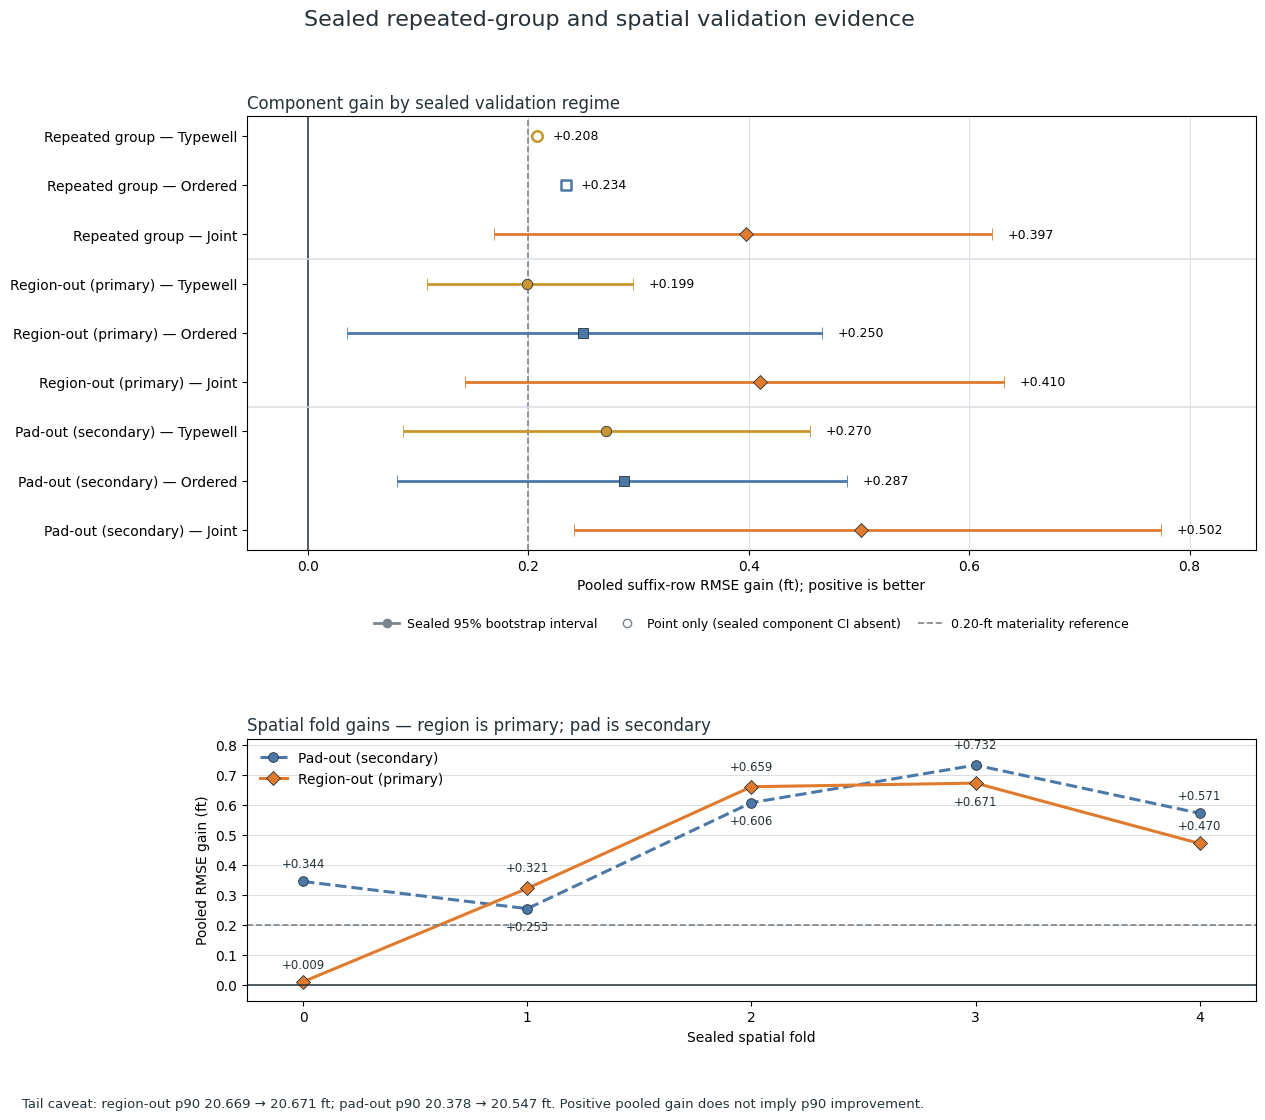

Saved C:\PRIMEdEV-1\GeoSteerN-Codex\.claude\worktrees\well-datum-surface-fit-e24e6c\research\results\sealed_validation_summary.png
PNG SHA-256: dbdf6f57e520230c60ec46bd881064840c52b02e8776c28853b6d44810954cfe


In [4]:
from matplotlib.lines import Line2D

component_colors = {"typewell": "#C7962E", "ordered": "#4C78A8", "joint": "#E07A2D"}
component_markers = {"typewell": "o", "ordered": "s", "joint": "D"}
charcoal, grid, neutral = "#263238", "#D9DEE3", "#7A848B"

component_plot = component_evidence.copy()
regime_labels = {
    "repeated": "Repeated group",
    "region_out": "Region-out (primary)",
    "pad_out": "Pad-out (secondary)",
}
component_plot["plot_label"] = component_plot.apply(
    lambda row: f"{regime_labels[row.regime_key]} — {row.component.title()}", axis=1
)
component_plot["y"] = np.arange(len(component_plot))

fig, (gain_ax, fold_ax) = plt.subplots(
    2, 1, figsize=(13.5, 11.5), gridspec_kw={"height_ratios": [1.65, 1.0]}
)
for _, row in component_plot.iterrows():
    color = component_colors[row.component]
    marker = component_markers[row.component]
    if np.isfinite(row.ci95_low_ft):
        left = row.gain_ft - row.ci95_low_ft
        right = row.ci95_high_ft - row.gain_ft
        gain_ax.errorbar(
            row.gain_ft, row.y, xerr=np.array([[left], [right]]), fmt=marker,
            color=color, ecolor=color, markeredgecolor=charcoal, markeredgewidth=0.6,
            markersize=7.5, linewidth=2.0, capsize=4, zorder=3,
        )
        label_x = row.ci95_high_ft + 0.014
    else:
        gain_ax.scatter(
            row.gain_ft, row.y, marker=marker, s=58, facecolors="white",
            edgecolors=color, linewidths=1.8, zorder=3,
        )
        label_x = row.gain_ft + 0.014
    gain_ax.text(label_x, row.y, f"{row.gain_ft:+.3f}", va="center", ha="left", fontsize=9)

gain_ax.axvline(0, color=charcoal, linewidth=1.1)
gain_ax.axvline(0.20, color=neutral, linewidth=1.2, linestyle="--")
gain_ax.axhline(2.5, color=grid, linewidth=1.1)
gain_ax.axhline(5.5, color=grid, linewidth=1.1)
gain_ax.set_yticks(component_plot.y, component_plot.plot_label)
gain_ax.invert_yaxis()
gain_ax.set_xlim(-0.055, 0.86)
gain_ax.set_xlabel("Pooled suffix-row RMSE gain (ft); positive is better")
gain_ax.set_title("Component gain by sealed validation regime", loc="left", color=charcoal)
gain_ax.grid(axis="x", color=grid, linewidth=0.7)
gain_ax.set_axisbelow(True)
gain_ax.legend(
    handles=[
        Line2D([0], [0], color=neutral, marker="o", linewidth=2, label="Sealed 95% bootstrap interval"),
        Line2D([0], [0], color=neutral, marker="o", markerfacecolor="white", linewidth=0,
               label="Point only (sealed component CI absent)"),
        Line2D([0], [0], color=neutral, linestyle="--", linewidth=1.2, label="0.20-ft materiality reference"),
    ],
    loc="upper center", bbox_to_anchor=(0.5, -0.13), ncol=3,
    frameon=False, fontsize=9, handletextpad=0.6, columnspacing=1.4,
)

fold_styles = {
    "Region-out (primary)": {"color": "#E07A2D", "marker": "D", "linestyle": "-"},
    "Pad-out (secondary)": {"color": "#4C78A8", "marker": "o", "linestyle": "--"},
}
for label, frame in spatial_fold_gains.groupby("validation_regime", sort=False):
    style = fold_styles[label]
    fold_ax.plot(
        frame.fold, frame.gain_ft, label=label, linewidth=2.2, markersize=7,
        markeredgecolor=charcoal, markeredgewidth=0.6, **style,
    )
    for _, row in frame.iterrows():
        close_pair_offsets = {
            ("Region-out (primary)", 1): 0.048,
            ("Pad-out (secondary)", 1): -0.040,
            ("Region-out (primary)", 2): 0.045,
            ("Pad-out (secondary)", 2): -0.040,
            ("Region-out (primary)", 3): -0.040,
            ("Pad-out (secondary)", 3): 0.045,
        }
        offset = close_pair_offsets.get((label, int(row.fold)), 0.036)
        fold_ax.text(
            row.fold, row.gain_ft + offset, f"{row.gain_ft:+.3f}",
            ha="center", va="bottom" if offset > 0 else "top", fontsize=8.5, color=charcoal,
        )

fold_ax.axhline(0, color=charcoal, linewidth=1.1)
fold_ax.axhline(0.20, color=neutral, linewidth=1.2, linestyle="--")
fold_ax.set_xticks(range(5))
fold_ax.set_xlim(-0.25, 4.25)
fold_ax.set_ylim(-0.055, 0.82)
fold_ax.set_xlabel("Sealed spatial fold")
fold_ax.set_ylabel("Pooled RMSE gain (ft)")
fold_ax.set_title("Spatial fold gains — region is primary; pad is secondary", loc="left", color=charcoal)
fold_ax.grid(axis="y", color=grid, linewidth=0.7)
fold_ax.set_axisbelow(True)
fold_ax.legend(loc="upper left", frameon=False)

fig.suptitle("Sealed repeated-group and spatial validation evidence", fontsize=16, color=charcoal, y=0.985)
tail_note = (
    f"Tail caveat: region-out p90 {region_aggregate['p90_base_well_rmse']:.3f} → "
    f"{region_aggregate['p90_candidate_well_rmse']:.3f} ft; pad-out p90 "
    f"{pad_aggregate['p90_base_well_rmse']:.3f} → {pad_aggregate['p90_candidate_well_rmse']:.3f} ft. "
    "Positive pooled gain does not imply p90 improvement."
)
fig.text(0.065, 0.028, tail_note, ha="left", va="bottom", fontsize=9.5, color=charcoal)
fig.tight_layout(rect=[0.045, 0.072, 0.99, 0.955], h_pad=5.2)

SEALED_FIGURE_PATH = SEALED_RESULT_DIR / "sealed_validation_summary.png"
fig.savefig(SEALED_FIGURE_PATH, dpi=180, bbox_inches="tight", facecolor="white")
plt.show()
sealed_figure_sha256 = file_sha256(SEALED_FIGURE_PATH)
assert SEALED_FIGURE_PATH.stat().st_size > 100_000
print(f"Saved {SEALED_FIGURE_PATH}")
print(f"PNG SHA-256: {sealed_figure_sha256}")

## Context & Methods

The geological object is a well trajectory through an ordered stratigraphic contact
complex. Gamma ray is treated as interval/package evidence, not an independent point
label. The experiment compares:

1. an inherited, own-well inference-safe policy baseline;
2. **equal-cell typewell transport**, where every occupied predicted TVT cell receives
   equal weight and carries empirical GR quartiles;
3. **ordered reversible transport**, a frozen Viterbi solver with stay/cross/reverse
   transitions and 13-sample ordered windows across ±90 MD;
4. simple and two-coefficient combinations of the two complementary corrections.

### Key Assumptions

- Allowed validation inputs are horizontal `MD,X,Y,Z,GR,TVT_input` and typewell
  `TVT,GR` only.
- Suffix `TVT`, formation surfaces, typewell `Geology`, PNGs, and ID lookup are forbidden.
- Three exact train/test-overlap IDs are excluded before any split.
- Exact duplicate typewell profiles stay on one side of the outer split.
- Primary score is pooled station-level RMSE; per-well statistics are diagnostic.
- Ordered diagnostic correction magnitudes in the raw artifact precede the fitted
  0.18335 correction shrink.

In [5]:
from pathlib import Path
import hashlib
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT_HINT = Path('C:\\PRIMEdEV-1\\GeoSteerN-Codex\\.claude\\worktrees\\well-datum-surface-fit-e24e6c')
root_candidates = [Path.cwd(), *Path.cwd().parents, ROOT_HINT]
ROOT = next(
    (path for path in root_candidates if (path / "research" / "results").exists()),
    None,
)
if ROOT is None:
    raise FileNotFoundError(
        "Cannot locate research/results; set the notebook working directory to the worktree."
    )
RESULT_DIR = ROOT / "research" / "results"
RESULT_PATH = RESULT_DIR / "interval_gate_strict_confirm_v2.json"
PER_WELL_PATH = RESULT_DIR / "interval_gate_strict_confirm_v2_per_well.csv"
FOLD_PATH = RESULT_DIR / "interval_gate_strict_confirm_v2_fold_manifest.csv"
PROVENANCE_PATH = RESULT_DIR / "interval_gate_strict_confirm_v2_provenance.json"
FIGURE_PATH = RESULT_DIR / "interval_gate_strict_confirm_v2_summary.png"

result = json.loads(RESULT_PATH.read_text(encoding="utf-8"))
per_well = pd.read_csv(PER_WELL_PATH)
folds = pd.read_csv(FOLD_PATH)
provenance = json.loads(PROVENANCE_PATH.read_text(encoding="utf-8"))
print(f"Loaded {len(folds)} eligible wells; {len(per_well)} holdout wells.")

Loaded 770 eligible wells; 272 holdout wells.


## Data

In [6]:
excluded = set(result["excluded_test_overlap_ids"])
dev_groups = set(folds.loc[folds.split == "dev", "typewell_profile_hash"])
hold_groups = set(folds.loc[folds.split == "holdout", "typewell_profile_hash"])
hold_rows = int(folds.loc[folds.split == "holdout", "suffix_rows"].sum())

assert excluded == {"000d7d20", "00bbac68", "00e12e8b"}
assert len(folds) == 770
assert folds.typewell_profile_hash.nunique() == 749
assert not (dev_groups & hold_groups)
assert hold_rows == 1_324_387 == result["base_model"]["holdout"]["n_rows"]
assert result["evaluation_stride"] == 1
assert provenance["status"] == "MEASURE_ONLY_NOT_OPEN"

def sha256_file(path):
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for block in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()

tracked_paths = {
    "research/interval_gate.py": ROOT / "research" / "interval_gate.py",
    "research/ordered_transport.py": ROOT / "research" / "ordered_transport.py",
    "research/test_interval_gate.py": ROOT / "research" / "test_interval_gate.py",
    "research/test_ordered_transport.py": ROOT / "research" / "test_ordered_transport.py",
    RESULT_PATH.name: RESULT_PATH,
    FOLD_PATH.name: FOLD_PATH,
    "competition_pdf": (
        Path(provenance["data_dir"]) / "AI_wellbore_geology_prediction_task_en.pdf"
    ),
}
verified_hashes = {name: sha256_file(path) for name, path in tracked_paths.items()}
assert verified_hashes == provenance["sha256"]

data_summary = pd.DataFrame({
    "measure": [
        "eligible wells", "unique typewell groups", "development wells",
        "holdout wells", "holdout suffix rows",
        "mean per-well holdout GR valid fraction", "provenance hashes verified"
    ],
    "value": [
        len(folds), folds.typewell_profile_hash.nunique(),
        int((folds.split == "dev").sum()), int((folds.split == "holdout").sum()),
        hold_rows,
        folds.loc[folds.split == "holdout", "gr_valid_fraction"].mean(),
        verified_hashes == provenance["sha256"],
    ],
})
data_summary

,measure,value
0,eligible wells,770
1,unique typewell groups,749
2,development wells,498
3,holdout wells,272
4,holdout suffix rows,1324387
5,mean per-well holdout GR valid fraction,0.726577
6,provenance hashes verified,True


## Results

In [7]:
baseline_rmse = result["base_model"]["holdout"]["pooled_row_rmse"]
display_names = {
    "typewell_equal_cell": "Equal-cell typewell",
    "prefix_equal_cell": "Prefix equal-cell",
    "fused_interval_ridge": "Landscape ridge",
    "ordered_transport_raw": "Ordered raw",
    "ordered_transport_calibrated": "Ordered calibrated",
    "equal_ordered_average": "Equal + ordered average",
    "equal_ordered_joint": "Equal + ordered joint",
}
rows = [{
    "method": "Baseline", "pooled_rmse_ft": baseline_rmse,
    "gain_ft": 0.0, "median_well_rmse_ft": result["base_model"]["holdout"]["median_well_rmse"],
    "p90_well_rmse_ft": result["base_model"]["holdout"]["p90_well_rmse"],
    "win_rate": np.nan,
}]
for key, label in display_names.items():
    candidate = result["candidates"][key]
    metric = candidate["holdout"]
    gain = candidate["holdout_gain"]
    rows.append({
        "method": label,
        "pooled_rmse_ft": metric["pooled_row_rmse"],
        "gain_ft": baseline_rmse - metric["pooled_row_rmse"],
        "median_well_rmse_ft": metric["median_well_rmse"],
        "p90_well_rmse_ft": metric["p90_well_rmse"],
        "win_rate": gain["win_rate"],
    })
comparison = pd.DataFrame(rows).sort_values("pooled_rmse_ft")
comparison.round(4)

,method,pooled_rmse_ft,gain_ft,median_well_rmse_ft,p90_well_rmse_ft,win_rate
7,Equal + ordered joint,14.1415,0.6924,8.4867,18.5181,0.5919
6,Equal + ordered average,14.3896,0.4443,8.9916,19.0661,0.6213
1,Equal-cell typewell,14.4374,0.3965,8.7867,19.3025,0.5257
5,Ordered calibrated,14.5011,0.3329,9.0328,19.4603,0.6434
3,Landscape ridge,14.5615,0.2724,8.8023,19.9333,0.4522
2,Prefix equal-cell,14.8236,0.0103,9.5080,20.0499,0.5368
0,Baseline,14.8339,0.0000,9.5637,20.1700,NaN
4,Ordered raw,16.3860,-1.5521,10.0435,24.9714,0.4449


In [8]:
# Anatomy of the headline fusion, fitted on development OOF corrections only.
joint_coefficients = result["candidates"]["equal_ordered_joint"][
    "coefficients_from_dev_oof"
]
typewell_shrink = result["candidates"]["typewell_equal_cell"][
    "calibrated_shift_shrink"
]
ordered_shrink = result["candidates"]["ordered_transport_calibrated"][
    "correction_shrink_from_dev_oof"
]
fusion_anatomy = pd.DataFrame({
    "component": ["Equal-cell typewell", "Ordered transport"],
    "raw_correction_shrink": [typewell_shrink, ordered_shrink],
    "joint_coefficient": [
        joint_coefficients["typewell_equal_cell"],
        joint_coefficients["ordered_transport"],
    ],
})
fusion_anatomy["effective_raw_multiplier"] = (
    fusion_anatomy.raw_correction_shrink * fusion_anatomy.joint_coefficient
)

base_well = pd.Series(result["base_model"]["holdout"]["per_well"])
typewell_well = pd.Series(
    result["candidates"]["typewell_equal_cell"]["holdout"]["per_well"]
)
ordered_well = pd.Series(
    result["candidates"]["ordered_transport_calibrated"]["holdout"]["per_well"]
)
component_gains = pd.DataFrame({
    "typewell_gain": base_well - typewell_well,
    "ordered_gain": base_well - ordered_well,
})
component_correlation = pd.DataFrame({
    "measure": ["Pearson", "Spearman"],
    "per_well_gain_correlation": [
        component_gains.corr(method="pearson").iloc[0, 1],
        component_gains.corr(method="spearman").iloc[0, 1],
    ],
})
display(fusion_anatomy.round(4), component_correlation.round(4))

,component,raw_correction_shrink,joint_coefficient,effective_raw_multiplier
0,Equal-cell typewell,0.4634,0.9991,0.4630
1,Ordered transport,0.1834,0.8592,0.1575


,measure,per_well_gain_correlation
0,Pearson,-0.0059
1,Spearman,0.1094


In [9]:
# Exact-typewell-group bootstrap: resample reference-log groups, not individual wells.
metric_by_well = pd.DataFrame({
    "well": sorted(result["base_model"]["holdout"]["per_well"]),
})
metric_by_well["base"] = metric_by_well.well.map(
    result["base_model"]["holdout"]["per_well"]
)
for key in ("typewell_equal_cell", "ordered_transport_calibrated",
            "equal_ordered_average", "equal_ordered_joint"):
    metric_by_well[key] = metric_by_well.well.map(
        result["candidates"][key]["holdout"]["per_well"]
    )
metric_by_well = metric_by_well.merge(
    folds.loc[folds.split == "holdout",
              ["well", "suffix_rows", "typewell_profile_hash"]],
    on="well", validate="one_to_one",
)

def group_bootstrap(candidate, draws=4000, seed=20260810):
    frame = metric_by_well.copy()
    frame["base_sse"] = frame.base.pow(2) * frame.suffix_rows
    frame["candidate_sse"] = frame[candidate].pow(2) * frame.suffix_rows
    grouped = frame.groupby("typewell_profile_hash").agg(
        base_sse=("base_sse", "sum"), candidate_sse=("candidate_sse", "sum"),
        rows=("suffix_rows", "sum"),
    )
    rng = np.random.default_rng(seed)
    samples = np.empty(draws)
    for i in range(draws):
        take = rng.integers(0, len(grouped), len(grouped))
        chosen = grouped.iloc[take]
        samples[i] = (
            np.sqrt(chosen.base_sse.sum() / chosen.rows.sum())
            - np.sqrt(chosen.candidate_sse.sum() / chosen.rows.sum())
        )
    observed = (
        np.sqrt(grouped.base_sse.sum() / grouped.rows.sum())
        - np.sqrt(grouped.candidate_sse.sum() / grouped.rows.sum())
    )
    return observed, np.quantile(samples, [0.025, 0.975])

ci_rows = []
for key, label in [
    ("typewell_equal_cell", "Equal-cell typewell"),
    ("ordered_transport_calibrated", "Ordered calibrated"),
    ("equal_ordered_average", "Equal + ordered average"),
    ("equal_ordered_joint", "Equal + ordered joint"),
]:
    observed, interval = group_bootstrap(key)
    ci_rows.append({"method": label, "gain_ft": observed,
                    "ci_low_ft": interval[0], "ci_high_ft": interval[1]})
confidence = pd.DataFrame(ci_rows)
confidence.round(4)

,method,gain_ft,ci_low_ft,ci_high_ft
0,Equal-cell typewell,0.3965,0.0925,0.6893
1,Ordered calibrated,0.3329,0.0758,0.6165
2,Equal + ordered average,0.4443,0.2627,0.6185
3,Equal + ordered joint,0.6924,0.3496,1.0245


### Visual contract

- **Question:** Which frozen interval corrections improve pooled competition RMSE, and
  which are harmful?
- **Takeaway:** Equal-cell and calibrated ordered evidence are complementary; their
  joint correction is strongest, while unconstrained ordered transport is harmful.
- **Form:** signed horizontal gain bars with a zero reference, plus group-bootstrap
  intervals for the four surviving candidates.
- **Data sufficiency:** eight methods and 265 independent typewell groups.
- **Palette:** one blue root for positive evidence, orange for negative evidence,
  charcoal references; signs, labels, and intervals provide non-color distinction.
- **Surface:** static Matplotlib figure embedded in this notebook and exported beside
  the result artifact.

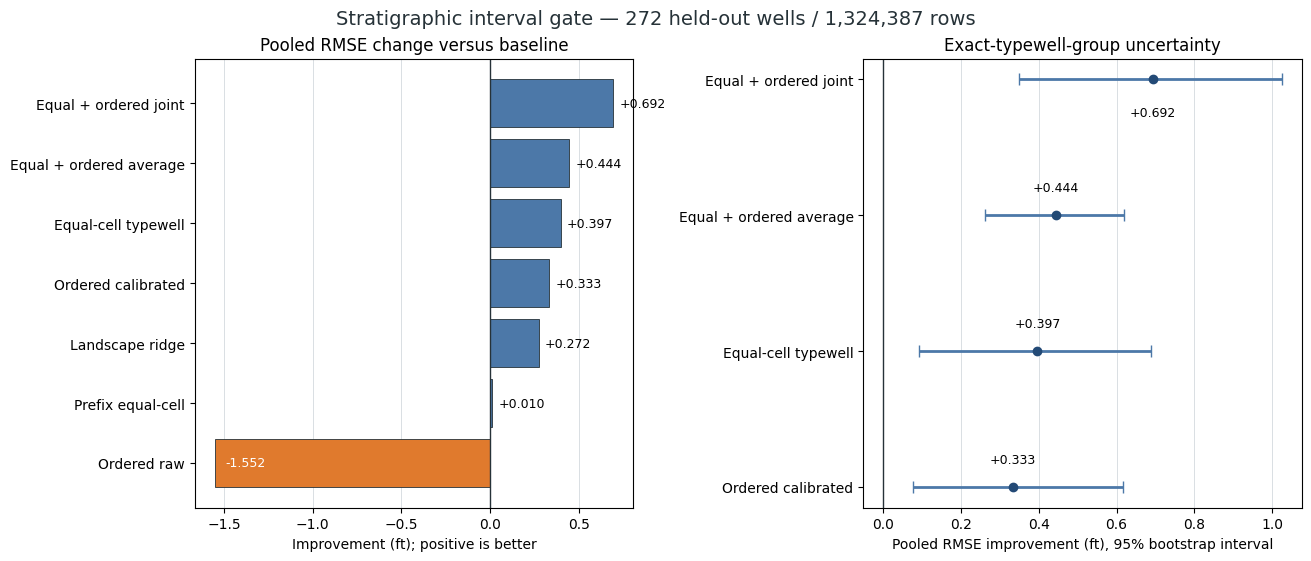

Saved C:\PRIMEdEV-1\GeoSteerN-Codex\.claude\worktrees\well-datum-surface-fit-e24e6c\research\results\interval_gate_strict_confirm_v2_summary.png


In [10]:
blue, blue_dark = "#4C78A8", "#234A76"
orange, charcoal, grid = "#E07A2D", "#263238", "#D9DEE3"
chart = comparison.loc[comparison.method != "Baseline"].sort_values("gain_ft")
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), constrained_layout=True)

colors = [blue if value >= 0 else orange for value in chart.gain_ft]
axes[0].barh(chart.method, chart.gain_ft, color=colors, edgecolor=charcoal, linewidth=0.6)
axes[0].axvline(0, color=charcoal, linewidth=1)
for y, value in enumerate(chart.gain_ft):
    if value >= 0:
        axes[0].text(value + 0.035, y, f"{value:+.3f}", va="center", ha="left", fontsize=9)
    else:
        axes[0].text(value + 0.06, y, f"{value:+.3f}", va="center", ha="left",
                     fontsize=9, color="white")
axes[0].set_title("Pooled RMSE change versus baseline")
axes[0].set_xlabel("Improvement (ft); positive is better")
axes[0].grid(axis="x", color=grid, linewidth=0.7)
axes[0].set_axisbelow(True)

ci_plot = confidence.sort_values("gain_ft")
xerr = np.vstack((ci_plot.gain_ft - ci_plot.ci_low_ft,
                  ci_plot.ci_high_ft - ci_plot.gain_ft))
axes[1].errorbar(ci_plot.gain_ft, ci_plot.method, xerr=xerr, fmt="o",
                 color=blue_dark, ecolor=blue, capsize=4, linewidth=2)
axes[1].axvline(0, color=charcoal, linewidth=1)
for y, value in enumerate(ci_plot.gain_ft):
    if y == len(ci_plot) - 1:
        axes[1].text(value, y - 0.20, f"{value:+.3f}", ha="center", va="top",
                     fontsize=9)
    else:
        axes[1].text(value, y + 0.18, f"{value:+.3f}", ha="center", fontsize=9)
axes[1].set_title("Exact-typewell-group uncertainty")
axes[1].set_xlabel("Pooled RMSE improvement (ft), 95% bootstrap interval")
axes[1].grid(axis="x", color=grid, linewidth=0.7)
axes[1].set_axisbelow(True)

fig.suptitle("Stratigraphic interval gate — 272 held-out wells / 1,324,387 rows",
             fontsize=14, color=charcoal)
fig.savefig(FIGURE_PATH, dpi=170, bbox_inches="tight", facecolor="white")
plt.show()
print(f"Saved {FIGURE_PATH}")

In [11]:
# Concentration audit for the exploratory joint fusion.
audit = metric_by_well.copy()
audit["base_sse"] = audit.base.pow(2) * audit.suffix_rows
audit["joint_sse"] = audit.equal_ordered_joint.pow(2) * audit.suffix_rows
audit["sse_gain"] = audit.base_sse - audit.joint_sse
positive = audit.loc[audit.sse_gain > 0].sort_values("sse_gain", ascending=False)
top10_share = positive.head(10).sse_gain.sum() / audit.sse_gain.sum()

removal = []
for n in (0, 1, 5, 10, 20):
    removed = set(positive.head(n).well)
    kept = audit.loc[~audit.well.isin(removed)]
    gain = (np.sqrt(kept.base_sse.sum() / kept.suffix_rows.sum())
            - np.sqrt(kept.joint_sse.sum() / kept.suffix_rows.sum()))
    removal.append({"top_positive_wells_removed": n, "pooled_gain_ft": gain})
print(f"Top-10 positive SSE share: {top10_share:.1%}")
pd.DataFrame(removal).round(4)

Top-10 positive SSE share: 67.4%


,top_positive_wells_removed,pooled_gain_ft
0,0,0.6924
1,1,0.5986
2,5,0.4070
3,10,0.2793
4,20,0.0649


## Takeaways

1. **The user’s interval interpretation survives measurement.** Equal-cell typewell
   evidence improves the strict full-row holdout by 0.397 ft pooled RMSE.
2. **Ordering adds a distinct surface.** Ordered transport has near-zero per-well gain
   correlation with equal-cell transport. After strong development-only restriction,
   it improves 64.3% of wells.
3. **Unrestricted topology is rejected.** Raw ordered transport worsens pooled RMSE by
   1.552 ft; its inferred reversals cannot yet be read literally as geological crossings.
4. **Complementarity is the strongest measured entry point.** The joint correction
   improves pooled RMSE by 0.692 ft, median-well RMSE by 1.077 ft, and p90 well RMSE by
   1.652 ft. Removing its ten strongest wells still leaves about 0.279 ft improvement.
5. **Residue remains.** Prefix-only transport is null, raw ordered transport is harmful,
   and the fusion reused a previously inspected holdout.

**Next gate:** freeze the equal-cell and ordered corrections exactly as encoded, then run
repeated outer folds grouped by exact typewell hash, followed by a spatial-block stress
test. No algorithm revision may occur between those frozen evaluations.